<a href="https://colab.research.google.com/github/natrask/PIMI-Lab/blob/main/Whitney_nonlinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#!/usr/bin/env python
# coding: utf-8
# In[91]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib.pyplot as plt
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.reset_default_graph()
config = tf.ConfigProto()
sess = tf.Session(config=config)

Instructions for updating:
non-resource variables are not supported in the long term


In [120]:
#Generate 1D finite element grid
Ntrainsteps = 10000
Ndata_0 = 10
Ndata = 2*Ndata_0
meshsize= 32
Npou = 4
Ndatasamples = 10
TOL = 1e-10
Nbatch = 2
N1forms = int(Npou*(Npou-1)/2)
h = 1./float(meshsize-1)
points = np.linspace(0,1,meshsize)

In [5]:
#Build combinatorial gradient matrix for fully connected graph
delta0 = np.zeros((N1forms,Npou))
cnt=0
for i in range(Npou):
    for j in range(Npou):
        if j > i:
            delta0[cnt][j] = 1.
            delta0[cnt][i] = -1.
            cnt += 1

In [6]:
# %% Build convex combination tensor to include Dirichlet BC lift on left and right
Wij_trainable = tf.Variable(np.random.normal(0,1,(Npou-2,meshsize-2)),dtype=np.float64)
Wij_block1=tf.concat([tf.ones((1,1),dtype=tf.float64),tf.zeros((1,meshsize-1),dtype=tf.float64)],axis=1)
Wij_block2=tf.concat([tf.zeros((Npou-2,1),dtype=tf.float64),tf.nn.softmax(Wij_trainable,axis=0),tf.zeros((Npou-2,1),dtype=tf.float64)],axis=1)
Wij_block3=tf.concat([tf.zeros((1,meshsize-1),dtype=tf.float64),tf.ones((1,1),dtype=tf.float64)],axis=1)
Wij=tf.concat([Wij_block1,Wij_block2,Wij_block3],axis=0)

In [7]:
#Functions to evaluate basis functions+derivatives on fine scale (phi) and coarse pou (psi)
def evalPhi_i(x):
    return tf.nn.relu(1.0-(tf.abs(tf.expand_dims(x,0)-tf.expand_dims(points,1)))/h)
def evalGradPhi_i(x):
    suppPhi = tf.cast(evalPhi_i(x)>0,tf.float64)
    signPlus = tf.cast(tf.expand_dims(points,1) > tf.expand_dims(x,0),tf.float64)
    signNeg = tf.cast(tf.expand_dims(points,1) <= tf.expand_dims(x,0),tf.float64)
    return suppPhi*(-signPlus+signNeg)/h
def evalPsi0(xeval):
    return tf.einsum('ij,jq->iq',Wij,evalPhi_i(xeval))
def evalPsi1(xeval):
    phii_gradphij = tf.expand_dims(tf.einsum('ij,jq->iq',Wij,evalPhi_i(xeval)),0)*tf.expand_dims(tf.einsum('ij,jq->iq',Wij,evalGradPhi_i(xeval)),1)
    mvec = tf.linalg.band_part(tf.ones((Npou,Npou), dtype=tf.float64), 0, -1) - tf.linalg.eye(Npou, dtype=tf.float64)
    idx = tf.cast(mvec, 'bool')
    return tf.boolean_mask(phii_gradphij - tf.transpose(phii_gradphij,[1,0,2]) , idx, axis=0)

In [8]:
#Evaluate mass matrices on fine (phi) and coarse(psi) grid for 0- and 1-forms
xql = points[:-1]+h*(0.5+1./(2.*np.sqrt(3)))
xqr = points[:-1]+h*(0.5-1./(2.*np.sqrt(3)))
xq = np.sort(np.concatenate([xql,xqr],axis=0))

#mass matrix of P1 basis functions
nodal_basisEval = evalPhi_i(xq)
Mnodal=(h/2.)*tf.reduce_sum(tf.expand_dims(nodal_basisEval,0)*tf.expand_dims(nodal_basisEval,1),axis=2)
#mass matrix of whitney 0-form basis functions
psi0_basisEval = evalPsi0(xq)
M0=(h/2.)*tf.reduce_sum(tf.expand_dims(psi0_basisEval,0)*tf.expand_dims(psi0_basisEval,1),axis=2)
#mass matrix of whitney 1-form basis functions
psi1_basisEval = evalPsi1(xq)
M1=tf.reshape((h/2.)*tf.reduce_sum(tf.expand_dims(psi1_basisEval,0)*tf.expand_dims(psi1_basisEval,1),axis=2),(N1forms,N1forms))
#compare to divmat = (psi1,grad psi0) bilinear form
divMat=(h/2.)*tf.reduce_sum(tf.expand_dims(psi1_basisEval,0)*tf.expand_dims(tf.einsum('ij,jq->iq',Wij,evalGradPhi_i(xq)),1),axis=2)
divMat2=-tf.einsum('ab,bc->ac',delta0.T,M1)

In [148]:
#Construct tf variables for holding solution and lagrange multipliers
uhat = tf.placeholder(shape=(Nbatch,Npou),dtype=tf.float64)
fhat = tf.placeholder(shape=(Nbatch,Npou),dtype=tf.float64)
u_eval = tf.einsum('ix,di->dx',psi0_basisEval,uhat)
u_target = tf.placeholder(shape=(Nbatch,xq.shape[0]),dtype=tf.float64)
lam = tf.placeholder(shape=(Nbatch,Npou),dtype=tf.float64)
mu_cond = tf.exp(tf.Variable(0.0,dtype=tf.float64))

In [164]:
#Construct neural network N[u] mapping from uhat to N[uhat] \in R^{Nbatch x N1forms)
#    and also collect Jacobian J_N[u]
DNN_width = 10
NNhidden0_N = tf.layers.Dense(DNN_width,activation='tanh')
NNhidden1_N = tf.layers.Dense(DNN_width,activation='tanh')
# NNlinear_N  = tf.layers.Dense(N1forms,activation='linear') #come back and make this initialized to zero so we start from a linear model
NNlinear_N  = tf.Variable(np.zeros((N1forms,DNN_width)),dtype=tf.float64)
def nonlinearityNN(x):
  #return x #use to check the correct execution of the jacobian
  hiddenOutput = NNhidden1_N(NNhidden0_N(x))
  return tf.einsum('ew,bw->be',NNlinear_N,hiddenOutput)
N_u = 0.0*nonlinearityNN(uhat) #switch 1.0 or 0.0 to turn nonlinearity on/off
JN_u = tf.stack([tf.gradients(N_u[:,e],uhat)[0] for e in range(N1forms)],axis=1)

In [165]:
#Now have necessary things declared to construct and evaluate fluxes + evaluate residual
Fhat = mu_cond*tf.einsum('ne,dn->de',divMat2,uhat) + N_u
F_eval = tf.einsum('ix,di->dx',psi1_basisEval,Fhat)
PDE_res = tf.einsum('ne,de->dn',divMat2,Fhat) - fhat

In [166]:
#Functions to extract the linearized system dynamics to be later used in newton raphson

#Jacobian of complete nonlinear system, which folds in the edgewise jacobian JN_u
A1 = mu_cond*tf.expand_dims(tf.einsum('ij,jk,kl->il',delta0.T,M1,delta0),0)
A2 = tf.einsum('ne,bem->bnm',delta0.T,JN_u)
A = A1+A2

#Corresponding RHS
b1 = fhat #note that fhat is going to hold all of the forcing - body force (f,q) + boundary flux <F,q>
b2 = -tf.einsum('ne,be->bn',delta0.T,N_u)
b3 = tf.einsum('ne,bem,bm->bn',delta0.T,JN_u,uhat)
b = tf.expand_dims(b1+b2+b3,-1)

#Tensorflow hook to solve newton step and overwrite current value for uhat
unew = tf.linalg.lstsq(A,b,l2_regularizer=1e-8)[:,:,0]
#u_update = uhat.assign(unew)

In [167]:
#Build up loss and lagrange multiplier solver
LOSS_fit = tf.reduce_sum((u_eval-u_target)**2)
LOSS_pde = tf.einsum('bn,bn->',lam,PDE_res)
LOSS = LOSS_fit+LOSS_pde
#Adjoint solve
rhs_adj = -tf.expand_dims(tf.gradients(LOSS_fit,uhat)[0],-1)
lambdanew = tf.linalg.lstsq(tf.transpose(A,(0,2,1)),rhs_adj,l2_regularizer=1e-8)[:,:,0]
#lam_update = lam.assign(lambdanew)

In [168]:
#Finally, set up optimizer and initialize tensorflow graph
optimizer = tf.train.AdamOptimizer(learning_rate=1e-5).minimize(LOSS)
sess.run(tf.global_variables_initializer()) #initialize model

In [169]:
#Generate dataset
xdata = xq#np.linspace(0,1,Ndatasamples)
uscale = np.linspace(1.,3,Nbatch)
eps = 0.05
usol = 1.-(1.-np.exp(xdata/eps))/(1. - np.exp(1./eps))
dxusol = (1./eps)*(np.exp(xdata/eps))/(1. - np.exp(1./eps))
udata = np.expand_dims(usol,1)*np.expand_dims(uscale,0)
udata = udata-udata.mean(axis=0) #for the neumann problem the solution needs to have zero mean
dxudata = np.expand_dims(dxusol,1)*np.expand_dims(uscale,0)
F_data = udata - eps*dxudata

In [170]:
qleft = sess.run(psi0_basisEval[:,0])
qright = sess.run(psi0_basisEval[:,-1])
Fleft = F_data[0,:]
Fright = F_data[-1,:]
FBC = np.einsum('n,d->nd',qright,Fright)-np.einsum('n,d->nd',qleft,Fleft)

In [171]:
PDE_res

<tf.Tensor 'sub_26:0' shape=(2, 4) dtype=float64>

In [1]:
#optionally reinitialize
#sess.run(tf.global_variables_initializer()) #initialize model
#Train model with uhat and lambda initialized to zero
uhat_np = np.zeros((Nbatch,Npou))
lam_np  = np.zeros((Nbatch,Npou))
whitneyDict = {fhat:FBC.T,u_target:udata.T,uhat:uhat_np,lam:lam_np}

for it in range(1+0*Ntrainsteps):
  for newton in range(10):
    uhat_np = sess.run(unew,feed_dict=whitneyDict)
    whitneyDict = {fhat:FBC.T,u_target:udata.T,uhat:uhat_np,lam:lam_np}
    print('---',np.mean(np.abs(sess.run(PDE_res,feed_dict=whitneyDict))))
  lam_np = sess.run(lambdanew,feed_dict=whitneyDict)
  whitneyDict = {fhat:FBC.T,u_target:udata.T,uhat:uhat_np,lam:lam_np}
  sess.run(optimizer,feed_dict=whitneyDict)
  if it%500==0:
    print(it,sess.run(LOSS_fit,feed_dict=whitneyDict),np.mean(np.abs(sess.run(PDE_res,feed_dict=whitneyDict))),sess.run(LOSS,feed_dict=whitneyDict))

NameError: name 'np' is not defined

In [179]:
Anp=sess.run(A,feed_dict=whitneyDict)
bnp=sess.run(b,feed_dict=whitneyDict)
uhatnp=sess.run(uhat,feed_dict=whitneyDict)
np.einsum('dij,dj->di',Anp,uhatnp)-bnp[:,:,0]

array([[-3.62793067e-07, -5.34018883e-07,  5.28233433e-07,
         3.68578517e-07],
       [-1.08837920e-06, -1.60205665e-06,  1.58470030e-06,
         1.10573555e-06]])

TensorShape([Dimension(2), Dimension(62)])

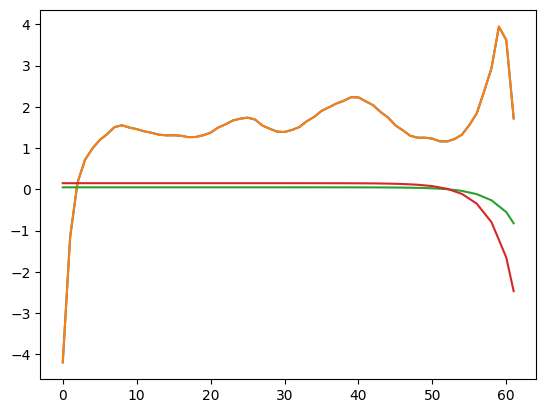

In [147]:
plt.plot(sess.run(u_eval,feed_dict=whitneyDict).T)
plt.plot(udata)
u_eval.shape
